Setup

In [ ]:
# Run if post_process = True in PARAMETERS (only need to run once at start of new runtime)
!pip install simplification

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 21.0 MB/s eta 0:00:00


Main

0: Loading image
     1.63 seconds
1a: Detecting Outlines
     0.28 seconds
2a: Defining filter
2a: Running filter
     2.53 seconds
3a: Removing small connected components from line image
     1.40 seconds
a: Dilating filtered lines for final stencil
     0.31 seconds
1b: Detecting background
     0.67 seconds
b: Solidifying footprints for result b
     2.07 seconds
Subtracting stencils
     0.17 seconds
Filtering small components for final result
     2.39 seconds
Removing border
     0.01 seconds
Writing output
     Done — written to V27S5_processed.tif


Post 1: Polygonizing raster
     Keeping Projection: EPSG:3857 (Ensure It's In Meters)
     159 polygons after polygonize
     1.09 seconds
Post 2: Removing holes
     0.01 seconds
Post 3: Buffering
     0.26 seconds
Post 4: Simplifying (Visvalingam-Whyatt)
     0.03 seconds
Post 5: De-Buffering
     0.03 seconds
Post 6: Simplifying (Douglas-Peucker)
     160 polygons in final output
     0.01 seconds
Post 7: Dissolving overlapping polygons
     160 polygons after dissolve
     0.02 seconds
Post 8: Final Buffering
     0.00 seconds
Writing GeoJSON to V27S5_processed.geojson
     0.56 seconds
Total Runtime: 17.18 seconds


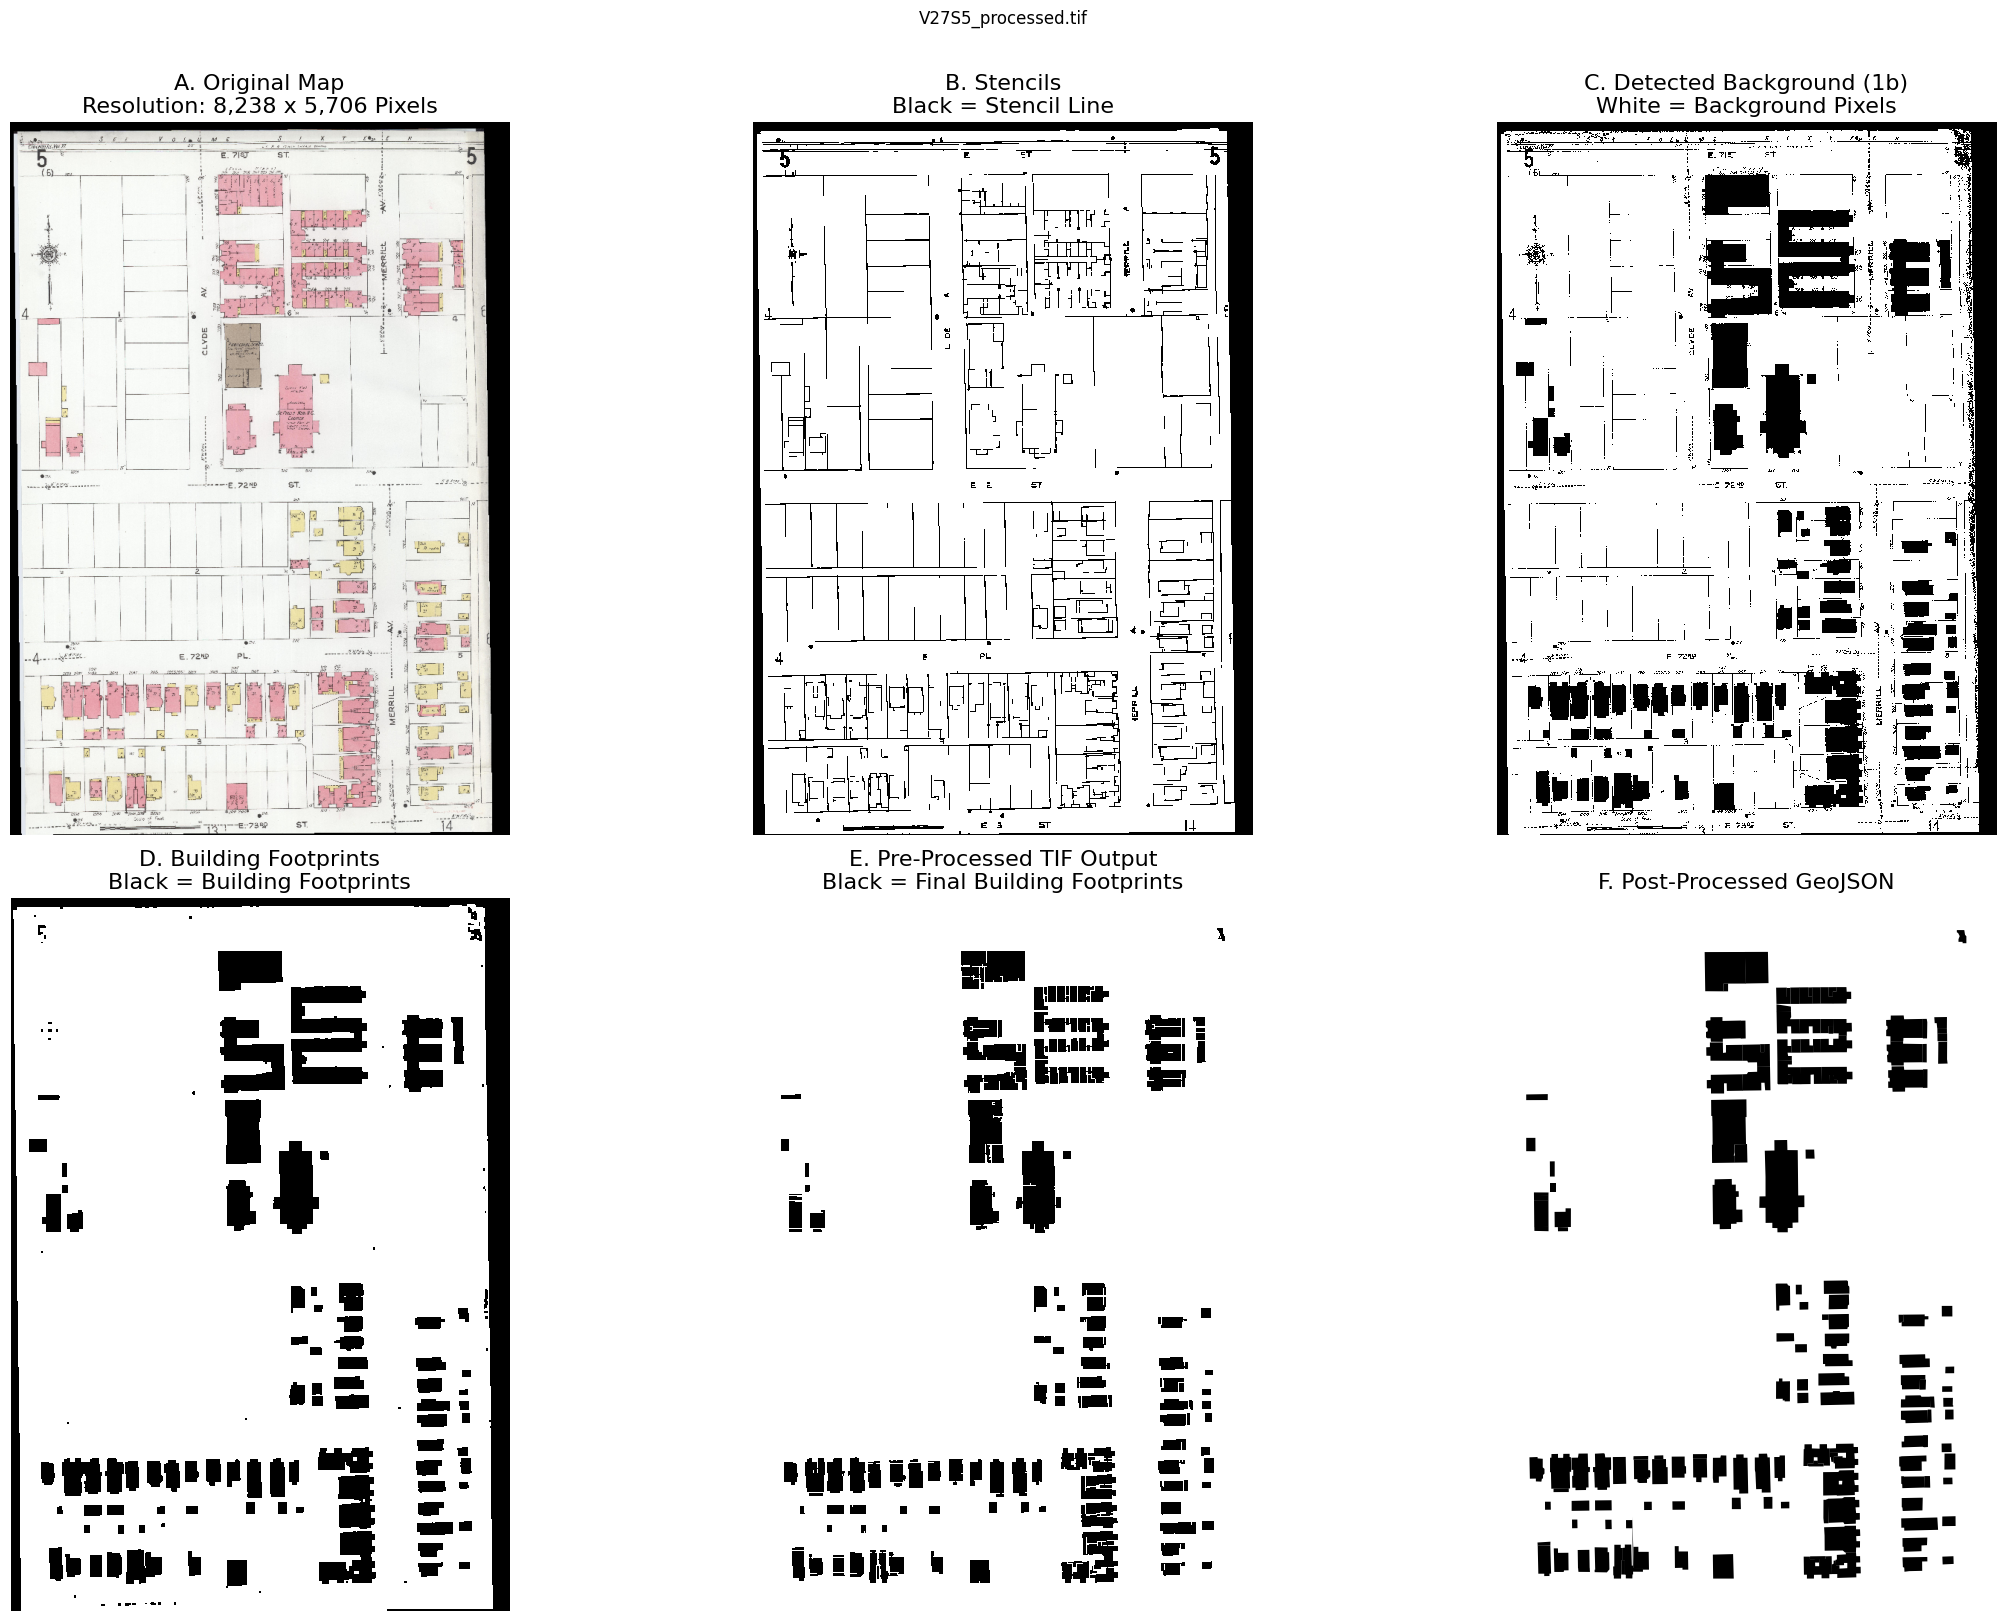

In [ ]:
import os
import time
import rasterio
import cv2
import numpy as np
from scipy.ndimage import label

# ── PARAMETERS ────────────────────────────────────────────────────────────────

original_map        = "V27S5.tif"   #Input Sanborn map (default settings for 8k x 5k resolution TIF)

dark_threshold      = 150   # Stencil: pixel value below which a pixel is considered black
min_length          = 20    # Stencil: minimum line length to keep (in pixels)
min_area_lines      = 700   # Stencil: min connected-component area (square pixels) to keep from line filter
dilation_modifier   = 7     # Stencil: dilation kernel size (7 = 7x7 pixel kernel)

white_threshold     = 210   # Background Colors: background white threshold (0 - 255.  Generally keep between 200 - 255)
gray_threshold      = 180   # Background Colors: background gray threshold (0 - 255.  Generally keep between 165 - 230.  Always keep below white_threshold)
use_yellow_thresh   = False # Background Colors: Set True if there are yellowed (e.g. discolored due to age) pixels in the image background
yellow_threshold    = 140   # Background Colors: background yellow threshold (keep or adjust if use_yellow_thresh = True)

erosion_size_1      = 5     # Footprints: initial erosion kernel size (5 = 5x5 pixel kernel)
closing_size        = 11    # Footprints: closing kernel size (11 = 11x11 pixel kernel)
erosion_size_2      = 3     # Footprints: post-closing erosion kernel size (3 = 3x3 pixel kernel)
line_removal_size   = 20    # Footprints: opening kernel size (removes parcel lines) (20 = 20x20 pixel kernel)
fp_min_area         = 130   # Footprints: post-parcel line removal noise filter threshold (square pixels)
remove_border       = True  # Footprints: Set True if there is a large black border to remove
border_width        = 300   # Footprints: Width/Length of pixels to be removed with border option above.  Adjust according to image resolution.
min_area_final      = 2500  # Footprints: min building footprint area (square pixels). Set to lower (e.g. 2500) to keep detached porches

post_process        = True  # Post: Enable vectorization and post-processing of output (geojson)
close_holes         = True  # Post: Remove holes (inner rings) in geojson
buffer_dist         = 1.3   # Post: Positive buffer to solidify polygons (meters)
simp_vw_tol         = 0.5   # Post: Visvalingam-Whyatt (area based) simplification (meters)
debuffer_dist       = -1.3  # Post: Negative buffer to return to original size (meters)
simp_dp_tol         = 0.25  # Post: Douglas-Peucker (distance based) simplification to remove duplicate and intermediary vertices (meters)
dissolve_polys      = True  # Post: Enable dissolving of polygons (to ensure no overlapping features)
final_buffer        = True  # Post: Enable final buffer (in case you want less pronounced separation between wall-to-wall building footprints)
final_buffer_dist   = 0.4   # Post: Distance (meters) for final buffer

display_output      = True  # Display: Display key (downscaled) outputs: Stencil (a), Footprints (b), Final Output
ds_factor           = 8     # Display: Downsampling factor

# ──────────────────────────────────────────────────────────────────────────────

global_start = time.time()
chunk_start = time.time()
print("0: Loading image")

with rasterio.open(original_map) as src:
    img_data = src.read().astype('uint8')
    base_profile = src.profile.copy()

num_bands, height, width = img_data.shape

now = time.time()
print(f"     {now - chunk_start:.2f} seconds")
chunk_start = now

# ── STEP 1a: Detect Outlines ──────────────────────────────────────────────────
print("1a: Detecting Outlines")
black_pixels = (
    (img_data[0] <= dark_threshold) &
    (img_data[1] <= dark_threshold) &
    (img_data[2] <= dark_threshold)
)
binary_image = np.where(black_pixels, np.uint8(0), np.uint8(255))

now = time.time()
print(f"     {now - chunk_start:.2f} seconds")
chunk_start = now

# ── STEP 2a: Filter out short lines ───────────────────────────────────────────
print("2a: Defining filter")
def filter_runs(binary_image, axis, min_len):
    """Keep only dark runs of length >= min_len along the given axis.
    Expects a binary image where dark pixels == 0 and light pixels == 255.
    """
    dark = binary_image == 0                        # Boolean mask — no re-detection needed
    output = np.full_like(binary_image, 255)        # Start all-white

    if axis == 0:                                   # Vertical: transpose so we always work on rows
        dark = dark.T
        output_view = output.T
    else:
        output_view = output

    for row_idx in range(dark.shape[0]):            # Loop over rows/cols
        row = dark[row_idx]
        padded = np.concatenate(([False], row, [False]))   # Pad so edges are detected correctly
        diff = np.diff(padded.astype(np.int8))             # +1 = run starts, -1 = run ends
        starts = np.where(diff == 1)[0]                    # Indices where dark runs begin
        ends   = np.where(diff == -1)[0]                   # Indices where dark runs end
        for s, e in zip(starts, ends):
            if e - s >= min_len:                           # Only keep runs long enough
                output_view[row_idx, s:e] = 0              # Write dark directly — no pixel lookup needed

    return output

print("2a: Running filter")

h_filtered = filter_runs(binary_image, axis=1, min_len=min_length)
v_filtered = filter_runs(binary_image, axis=0, min_len=min_length)
combined = np.where((h_filtered == 0) | (v_filtered == 0), np.uint8(0), np.uint8(255))

now = time.time()
print(f"     {now - chunk_start:.2f} seconds")
chunk_start = now

# ── STEP 3a: Remove small connected components from line image ────────────────
print("3a: Removing small connected components from line image")
fore_mask = combined == 0
lbl, _ = label(fore_mask)
sizes = np.bincount(lbl.ravel())
sizes[0] = 0
valid = np.where(sizes >= min_area_lines)[0]
keep_mask = np.isin(lbl, valid)

now = time.time()
print(f"     {now - chunk_start:.2f} seconds")
chunk_start = now

# ── STENCIL (a): Dilate filtered lines ────────────────────────────────────────
print("a: Dilating filtered lines for final stencil")
fore_stencil = keep_mask
dil_elem = np.ones((dilation_modifier, dilation_modifier), np.uint8)
dilated_mask = cv2.dilate(fore_stencil.astype(np.uint8), dil_elem, iterations=1, borderType=cv2.BORDER_CONSTANT, borderValue=0)
stencil = np.where(dilated_mask, np.uint8(0), np.uint8(255))  # 1-band

now = time.time()
print(f"     {now - chunk_start:.2f} seconds")
chunk_start = now

# ── STEP 1b: Detect background (white/gray/yellow areas) ──────────────────────
print("1b: Detecting background")
r, g, b = img_data[0], img_data[1], img_data[2]
white_px  = (r >= white_threshold) & (g >= white_threshold) & (b >= white_threshold)
gray_px   = ((r >= gray_threshold) & (r < white_threshold) &
             (g >= gray_threshold) & (g < white_threshold) &
             (b >= gray_threshold) & (b < white_threshold))

if use_yellow_thresh:
    yellow_px = ((b < r) & (r >= gray_threshold) &
                 (b < g) & (g >= gray_threshold) &
                 (b >= yellow_threshold))
    background = ~white_px & ~gray_px & ~yellow_px
else:
    background = ~white_px & ~gray_px

bg_uint8 = background.astype(np.uint8) * 255

now = time.time()
print(f"     {now - chunk_start:.2f} seconds")
chunk_start = now

# ── FOOTPRINTS (b): Solidify Footprints ───────────────────────────────────────
print("b: Solidifying footprints for result b")

kernel_e1   = np.ones((erosion_size_1, erosion_size_1), np.uint8)
eroded_bg   = cv2.erode(bg_uint8, kernel_e1, borderType=cv2.BORDER_CONSTANT, borderValue=0)

kernel_cl   = np.ones((closing_size, closing_size), np.uint8)
closed_bg   = cv2.morphologyEx(eroded_bg, cv2.MORPH_CLOSE, kernel_cl, borderType=cv2.BORDER_CONSTANT, borderValue=0)

kernel_e2   = np.ones((erosion_size_2, erosion_size_2), np.uint8)
eroded_fp   = cv2.erode(closed_bg, kernel_e2, borderType=cv2.BORDER_CONSTANT, borderValue=0)

kernel_lr   = np.ones((line_removal_size, line_removal_size), np.uint8)
opened_fp   = cv2.morphologyEx(eroded_fp, cv2.MORPH_OPEN, kernel_lr, borderType=cv2.BORDER_CONSTANT, borderValue=0)
opened_fp   = opened_fp > 0  # back to bool

lbl2, _     = label(opened_fp)
sizes2      = np.bincount(lbl2.ravel())
sizes2[0]   = 0
valid2      = np.where(sizes2 >= fp_min_area)[0]
filtered_fp = np.isin(lbl2, valid2)

now = time.time()
print(f"     {now - chunk_start:.2f} seconds")
chunk_start = now

# ── SUBTRACTED (c) ────────────────────────────────────────────────────────────
print("Subtracting stencils")

black_stencil = stencil == 0
combined_mask = filtered_fp & ~black_stencil
subtracted = np.where(combined_mask, np.uint8(0), np.uint8(255))

now = time.time()
print(f"     {now - chunk_start:.2f} seconds")
chunk_start = now

# ── FINAL: Filter small components ────────────────────────────────────────────
print("Filtering small components for final result")
lbl4, _ = label(subtracted <= 20)
sz4 = np.bincount(lbl4.ravel())
sz4[0] = 0
valid4 = np.where(sz4 >= min_area_final)[0]
final_mask = np.isin(lbl4, valid4)
final_img = np.where(final_mask, subtracted, np.uint8(255))

now = time.time()
print(f"     {now - chunk_start:.2f} seconds")
chunk_start = now

# ── OPTIONAL: Remove border ───────────────────────────────────────────────────
print("Removing border")
if remove_border:
    final_img[:border_width, :] = 255
    final_img[-border_width:, :] = 255
    final_img[:, :border_width] = 255
    final_img[:, -border_width:] = 255

    now = time.time()
    print(f"     {now - chunk_start:.2f} seconds")

# ── WRITE OUTPUT ──────────────────────────────────────────────────────────────
print("Writing output")
out_profile = base_profile.copy()
out_profile.pop('compress', None)
out_profile.pop('photometric', None)
out_profile.pop('tiled', None)
out_profile.pop('blockxsize', None)
out_profile.pop('blockysize', None)
out_profile.update(count=1, dtype='uint8', compress='deflate', photometric='minisblack')

output_file = os.path.splitext(original_map)[0] + "_processed.tif"

with rasterio.open(output_file, 'w', **out_profile) as dst:
    dst.write(final_img, 1)

print(f"     Done — written to {output_file}")

if not post_process:
  now = time.time()
  print(f"Total Runtime: {now - global_start:.2f} seconds")

# ── POST-PROCESSING: Vector output ────────────────────────────────────────────

if post_process:
    import geopandas as gpd
    import shapely
    from shapely.geometry import shape, Polygon
    from shapely.ops import unary_union
    from rasterio.features import shapes
    from simplification.cutil import simplify_coords_vw

    output_geojson = os.path.splitext(original_map)[0] + "_processed.geojson"

    # ── Step 1: Polygonize (raster to vector) ─────────────────────────────────
    chunk_start = time.time()
    print("Post 1: Polygonizing raster")

    band = final_img
    transform = base_profile['transform']
    crs = base_profile['crs']
    mask = (band == 0).astype(np.uint8)
    polys = [
        shape(geom)
        for geom, val in shapes(mask, mask=mask, connectivity=4, transform=transform)
    ]
    gdf = gpd.GeoDataFrame(geometry=polys, crs=crs)

    # Reproject to CRS in meters if source is geographic
    if gdf.crs and gdf.crs.is_geographic:
        utm_crs = gdf.estimate_utm_crs()
        print(f"     Reprojecting to {utm_crs}")
        gdf = gdf.to_crs(utm_crs)
    else:
        print(f"     Keeping Projection: {crs} (Ensure It's In Meters)")

    print(f"     {len(gdf)} polygons after polygonize")

    now = time.time()
    print(f"     {now - chunk_start:.2f} seconds")
    chunk_start = now

    # ── Step 2: Delete holes (remove all interior rings) ──────────────────────
    if close_holes:
        print("Post 2: Removing holes")
        def remove_holes(geom):
            if geom.geom_type == 'Polygon':
                return Polygon(geom.exterior)
            elif geom.geom_type == 'MultiPolygon':
                return shapely.multipolygons([Polygon(p.exterior) for p in geom.geoms])
            return geom

        gdf['geometry'] = gdf['geometry'].apply(remove_holes)

        now = time.time()
        print(f"     {now - chunk_start:.2f} seconds")
        chunk_start = now

    # ── Step 3: Buffer
    print("Post 3: Buffering")
    gdf['geometry'] = gdf['geometry'].buffer(
        buffer_dist,
        cap_style='square',
        join_style='mitre',
        mitre_limit=2000
    )

    now = time.time()
    print(f"     {now - chunk_start:.2f} seconds")
    chunk_start = now

    # ── Step 4: Simplify — Visvalingam-Whyatt
    print("Post 4: Simplifying (Visvalingam-Whyatt)")
    def simplify_vw(geom, tolerance):
        """Apply Visvalingam-Whyatt simplification to a polygon geometry."""
        def _simplify_ring(coords):
            arr = np.array(coords)
            simplified = simplify_coords_vw(arr, tolerance)
            if len(simplified) < 4:          # VW can collapse rings — keep original if too small
                return coords
            return simplified.tolist()

        if geom.geom_type == 'Polygon':
            exterior = _simplify_ring(list(geom.exterior.coords))
            interiors = [_simplify_ring(list(r.coords)) for r in geom.interiors]
            try:
                return Polygon(exterior, interiors)
            except Exception:
                return geom
        elif geom.geom_type == 'MultiPolygon':
            parts = [simplify_vw(p, tolerance) for p in geom.geoms]
            return shapely.multipolygons([p for p in parts if not p.is_empty])
        return geom

    gdf['geometry'] = gdf['geometry'].apply(lambda g: simplify_vw(g, simp_vw_tol))

    now = time.time()
    print(f"     {now - chunk_start:.2f} seconds")
    chunk_start = now

    # ── Step 5: De-Buffer
    print("Post 5: De-Buffering")
    gdf['geometry'] = gdf['geometry'].buffer(
        debuffer_dist,
        cap_style='square',
        join_style='mitre',
        mitre_limit=2000
    )
    # Negative buffer can produce empty or MultiPolygon geometries — explode and clean
    gdf = gdf[~gdf['geometry'].is_empty].explode(index_parts=False).reset_index(drop=True)

    now = time.time()
    print(f"     {now - chunk_start:.2f} seconds")
    chunk_start = now

    # ── Step 6: Simplify — Douglas-Peucker
    print("Post 6: Simplifying (Douglas-Peucker)")
    gdf['geometry'] = gdf['geometry'].simplify(simp_dp_tol, preserve_topology=True)
    gdf = gdf[~gdf['geometry'].is_empty].reset_index(drop=True)

    print(f"     {len(gdf)} polygons in final output")

    now = time.time()
    print(f"     {now - chunk_start:.2f} seconds")
    chunk_start = now

    if dissolve_polys:
        # ── Step 7: Dissolve
        print("Post 7: Dissolving overlapping polygons")
        dissolved = unary_union(gdf['geometry'])
        if dissolved.geom_type == 'Polygon':
            gdf = gpd.GeoDataFrame(geometry=[dissolved], crs=gdf.crs)
        else:  # MultiPolygon — explode back to individual features
            gdf = gpd.GeoDataFrame(geometry=list(dissolved.geoms), crs=gdf.crs)
        gdf = gdf[~gdf['geometry'].is_empty].reset_index(drop=True)

        print(f"     {len(gdf)} polygons after dissolve")

        now = time.time()
        print(f"     {now - chunk_start:.2f} seconds")
        chunk_start = now

    if final_buffer:
        # ── Step 8: Final Buffer
        print("Post 8: Final Buffering")
        gdf['geometry'] = gdf['geometry'].buffer(
            final_buffer_dist,
            cap_style='square',
            join_style='mitre',
            mitre_limit=2000
        )

        now = time.time()
        print(f"     {now - chunk_start:.2f} seconds")
        chunk_start = now

    # ── Write GeoJSON ─────────────────────────────────────────────────────────
    print(f"Writing GeoJSON to {output_geojson}")
    if gdf.crs != crs:
        gdf = gdf.to_crs(crs)
        print(f"     Reprojecting to {crs}")

    gdf.to_file(output_geojson, driver='GeoJSON')

    now = time.time()
    print(f"     {now - chunk_start:.2f} seconds")
    print(f"Total Runtime: {now - global_start:.2f} seconds")


# ── OPTIONAL: Display Output ──────────────────────────────────────────────────

if display_output:
    import matplotlib.pyplot as plt

    def downsample(arr, factor):
        """Downsample a 2D array by the given factor for display."""
        return arr[::factor, ::factor]

    orig_disp    = np.moveaxis(img_data[:3, ::ds_factor, ::ds_factor], 0, -1)
    bg_disp      = downsample(bg_uint8, ds_factor)
    stencil_disp = downsample(stencil, ds_factor)
    fp_disp      = downsample(np.where(filtered_fp, np.uint8(0), np.uint8(255)), ds_factor)

    with rasterio.open(output_file) as src:
        final_disp = src.read(1, out_shape=(src.height // ds_factor, src.width // ds_factor))

    gdf_display = gpd.read_file(output_geojson)

    panels = [
        (orig_disp,    'imshow_rgb', None,       "A. Original Map\nResolution: 8,238 x 5,706 Pixels"),
        (stencil_disp, 'imshow',     'binary_r', "B. Stencils\nBlack = Stencil Line"), #"Stencil (a)\nBlack = Stencil Line"
        (bg_disp,      'imshow',     'binary',   "C. Detected Background (1b)\nWhite = Background Pixels"), #"Detected Background (1b)\nWhite = Background Pixels"
        (fp_disp,      'imshow',     'binary_r', "D. Building Footprints\nBlack = Building Footprints"), #"Footprints (b)\nBlack = Building Footprints"
        (final_disp,   'imshow',     'binary_r', "E. Pre-Processed TIF Output\nBlack = Final Building Footprints"), #"Final Output\nBlack = Final Building Footprints"
        (gdf_display,  'vector',     None,       f"F. Post-Processed GeoJSON"), #"Post-Processed GeoJSON\n{len(gdf_display)} building footprints"
    ]

    fig, axes = plt.subplots(2, 3, figsize=(24, 16))

    for ax, (data, kind, cmap, title) in zip(axes.flat, panels):
        if kind == 'imshow_rgb':
            ax.imshow(data)
        elif kind == 'imshow':
            ax.imshow(data, cmap=cmap, interpolation='nearest')
        else:
            data.plot(ax=ax, facecolor='black', edgecolor='none')
        ax.set_title(title, fontsize=16)
        ax.axis('off')

    plt.suptitle(output_file, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

Default Parameters

In [ ]:
# ── DEFAULT PARAMETERS ────────────────────────────────────────────────────────

#original_map        = "1619_georeferenced.tif"   #Input Sanborn map (default settings for 8k x 5k resolution TIF)

#dark_threshold      = 150   # Stencil: pixel value below which a pixel is considered black
#min_length          = 20    # Stencil: minimum line length to keep (in pixels)
#min_area_lines      = 700   # Stencil: min connected-component area (square pixels) to keep from line filter
#dilation_modifier   = 7     # Stencil: dilation kernel size (7 = 7x7 pixel kernel)

#white_threshold     = 210   # Background Colors: background white threshold (0 - 255.  Generally keep between 200 - 255)
#gray_threshold      = 180   # Background Colors: background gray threshold (0 - 255.  Generally keep between 165 - 230.  Always keep below white_threshold)
#use_yellow_thresh   = False # Background Colors: Set True if there are yellowed (e.g. discolored due to age) pixels in the image background
#yellow_threshold    = 140   # Background Colors: background yellow threshold (keep or adjust if use_yellow_thresh = True)

#erosion_size_1      = 5     # Footprints: initial erosion kernel size (5 = 5x5 pixel kernel)
#closing_size        = 11    # Footprints: closing kernel size (11 = 11x11 pixel kernel)
#erosion_size_2      = 3     # Footprints: post-closing erosion kernel size (3 = 3x3 pixel kernel)
#line_removal_size   = 20    # Footprints: opening kernel size (removes parcel lines) (20 = 20x20 pixel kernel)
#fp_min_area         = 130   # Footprints: post-parcel line removal noise filter threshold (square pixels)
#remove_border       = True  # Footprints: Set True if there is a large black border to remove
#border_width        = 300   # Footprints: Width/Length of pixels to be removed with border option above.  Adjust according to image resolution.
#min_area_final      = 2500  # Footprints: min building footprint area (square pixels). Set to lower (e.g. 2500) to keep detached porches

#display_output      = True  # Display: Display key (downscaled) outputs: Stencil (a), Footprints (b), Final Output
#ds_factor           = 8     # Display: Downsampling factor

#post_process        = True  # Post: Enable vectorization and post-processing of output (geojson)
#close_holes         = True  # Post: Remove holes (inner rings) in geojson
#buffer_dist         = 1.3   # Post: Positive buffer to solidify polygons (meters)
#simp_vw_tol         = 0.5   # Post: Visvalingam-Whyatt (area based) simplification (meters)
#debuffer_dist       = -1.3  # Post: Negative buffer to return to original size (meters)
#simp_dp_tol         = 0.25  # Post: Douglas-Peucker (distance based) simplification to remove duplicate and intermediary vertices (meters)
#dissolve_polys      = True  # Post: Enable dissolving of polygons (to ensure no overlapping features)
#final_buffer        = True  # Post: Enable final buffer (in case you want less pronounced separation between wall-to-wall building footprints)
#final_buffer_dist   = 0.2   # Post: Distance (meters) for final buffer

# ──────────────────────────────────────────────────────────────────────────────